--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

--- Summary Statistics ---
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531    

<Figure size 1200x800 with 0 Axes>

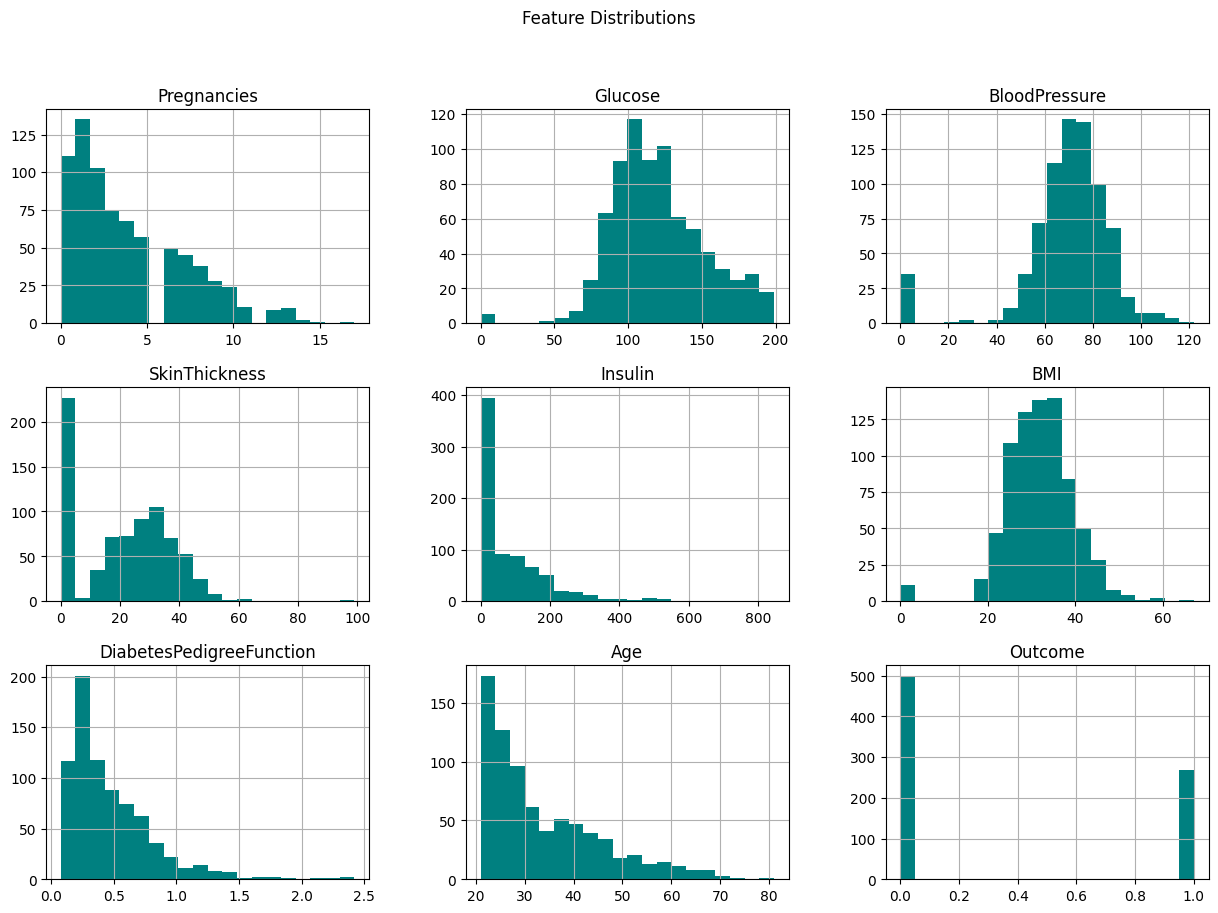

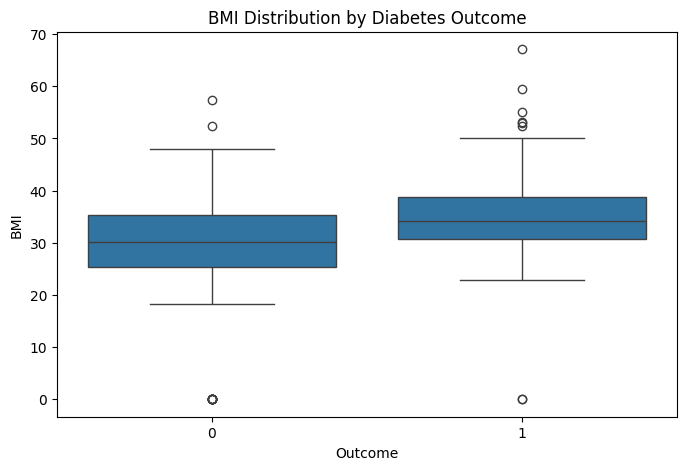

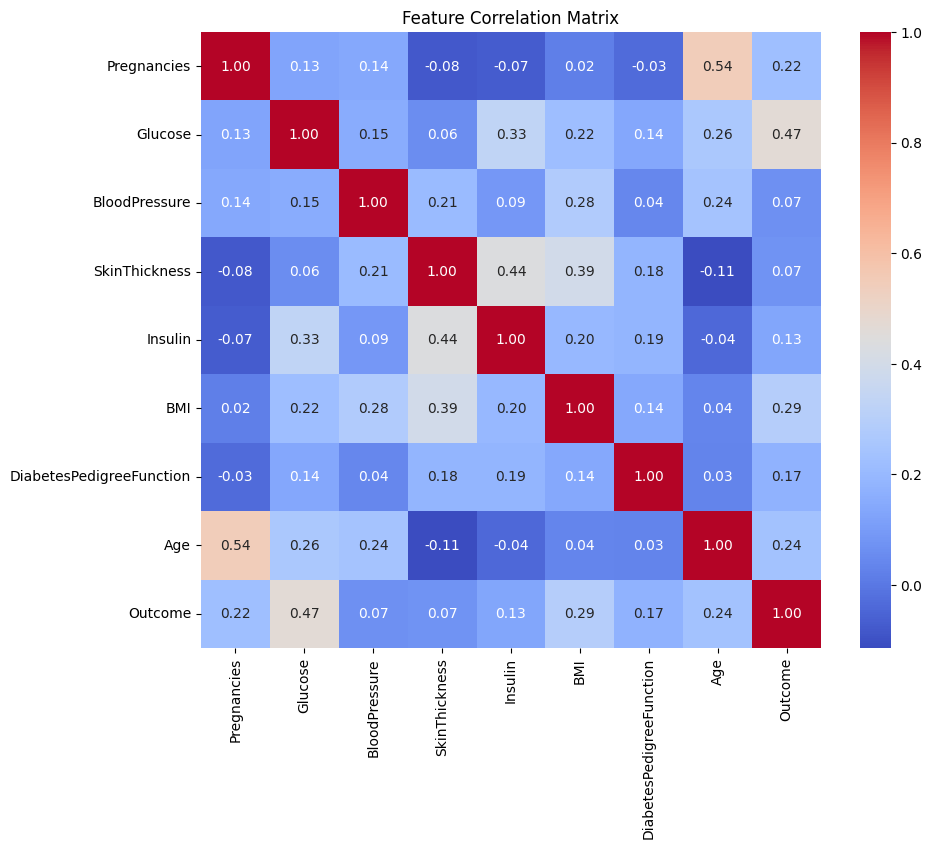

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# a. Load the dataset
df = pd.read_csv('/content/diabetes.csv')

# b. Examine features, types, and summary statistics
print("--- Dataset Info ---")
print(df.info())
print("\n--- Summary Statistics ---")
print(df.describe())
print("\n--- IsNULL Values ---")
print(df.isnull())

# c. Visualizations
plt.figure(figsize=(12, 8))

# Histogram for distributions
df.hist(bins=20, figsize=(15, 10), color='teal')
plt.suptitle("Feature Distributions")
plt.show()

# Box plot to check for outliers (e.g., BMI vs Outcome)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title("BMI Distribution by Diabetes Outcome")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 2a. Handle missing values
# Replacing 0 with NaN in columns where 0 is physically impossible
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

# Impute missing values with the median
imputer = SimpleImputer(strategy='median')
df[cols_to_fix] = imputer.fit_transform(df[cols_to_fix])

# 2b. Encode categorical variables
# (The diabetes dataset is usually numeric, but if you had categories, you'd use pd.get_dummies here)

# Prepare Features and Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Crucial for Logistic Regression performance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3a. Build the model
log_reg = LogisticRegression()

# 3b. Train the model
log_reg.fit(X_train_scaled, y_train)

print("Model Training Complete.")
print(f"Training Accuracy: {log_reg.score(X_train_scaled, y_train):.2%}")

Model Training Complete.
Training Accuracy: 77.04%


--- Model Performance Metrics ---
Accuracy: 0.7532
Precision: 0.6667
Recall: 0.6182
F1-Score: 0.6415
ROC-AUC: 0.8228


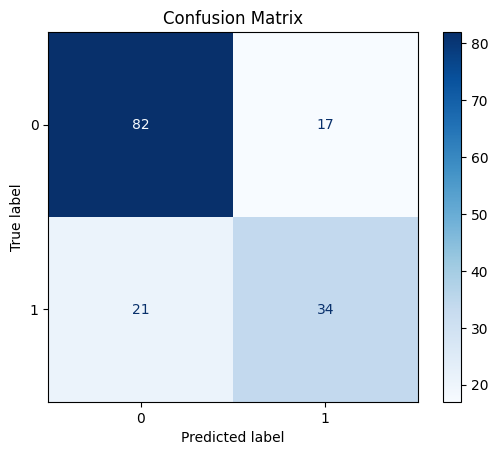

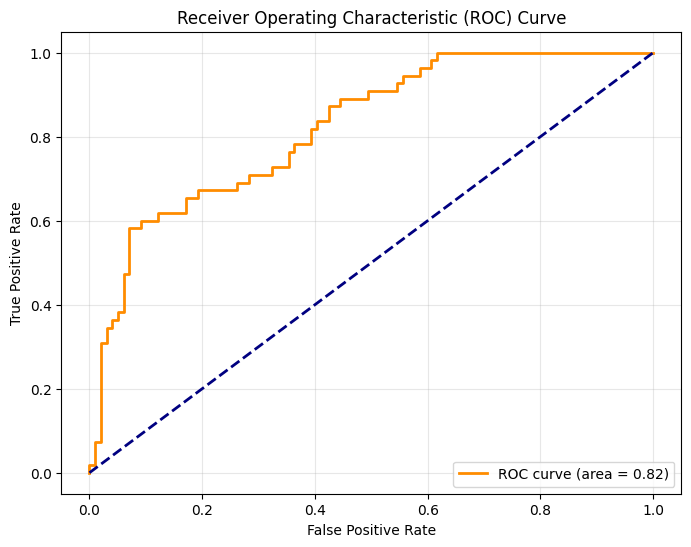

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# 4a. Evaluate performance on testing data
# Make predictions on the scaled test set
y_pred = log_reg.predict(X_test_scaled)
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1] # Probabilities for ROC-AUC

# Calculate Metrics
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_probs)
}

print("--- Model Performance Metrics ---")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# Visualize the Confusion Matrix
ConfusionMatrixDisplay.from_estimator(log_reg, X_test_scaled, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Visualize the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {metrics["ROC-AUC"]:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Create a DataFrame for easy viewing
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
})

# Sort by absolute value to see the most impactful features
importance['Abs_Coefficient'] = importance['Coefficient'].abs()
importance = importance.sort_values(by='Abs_Coefficient', ascending=False)

print(importance[['Feature', 'Coefficient']])

                    Feature  Coefficient
1                   Glucose     1.102682
5                       BMI     0.688839
7                       Age     0.392410
0               Pregnancies     0.222978
6  DiabetesPedigreeFunction     0.203635
2             BloodPressure    -0.151540
4                   Insulin    -0.138252
3             SkinThickness     0.068836


## b. Significance of Features
In a "Survival" context (commonly seen in datasets like the Titanic), certain features traditionally hold more weight. To determine significance, we look at:

1. The Sign and WeightIf "Age" has a negative coefficient, it implies older individuals had a lower probability of survival. If "Fare" has a positive coefficient, higher-paying passengers had a better chance.

2. Feature Odds RatioTo make these numbers more "human-readable," we calculate the Odds Ratio by taking the exponent of the coefficient ($e^{\beta}$).

Odds Ratio > 1: For every unit increase in the feature, the odds of survival increase by a factor of that ratio.

Odds Ratio < 1: The odds of survival decrease.

3. Practical SignificanceIn health or survival data, features like Glucose levels (in diabetes) or Class/Gender (in Titanic survival) usually show the highest significance. Statistical significance is often confirmed via p-values; if a p-value is less than 0.05, the feature is considered a reliable predictor.

##Question 1: What is the difference between precision and recall?

Precision: Measures the accuracy of positive predictions. It calculates the ratio of True Positives to the total number of positive predictions (True Positives + False Positives). It answers the question: "Of all patients predicted to have diabetes, how many actually had it?".

Recall (Sensitivity): Measures the ability of the model to find all positive instances. It calculates the ratio of True Positives to the total number of actual positives (True Positives + False Negatives). It answers the question: "Of all patients who actually had diabetes, how many did the model correctly identify?".


##Question 2: What is cross-validation, and why is it important in binary classification?


Definition: Cross-validation (such as K-Fold) involves splitting the dataset into 'k' subsets. The model is trained 'k' times, using a different subset as the test set each time while the remaining 'k-1' subsets serve as training data.


Importance: It prevents "overfitting" by ensuring the model is not tuned only to a specific training set. It provides a more robust and generalized estimate of model performance metrics like Accuracy and ROC-AUC. This is particularly critical in binary classification when classes are imbalanced